In [32]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, cross_validate, ShuffleSplit, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
housing = fetch_california_housing(as_frame=True)
print(f'type housing: {type(housing)}')
print(f'description data set: {housing.DESCR}')
print(f'features: {housing.feature_names}')

type housing: <class 'sklearn.utils._bunch.Bunch'>
description data set: .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).


In [3]:
features, target = housing.data, housing.target
print(f'type features: {type(features)}')
print(f'type target: {type(target)}')

type features: <class 'pandas.core.frame.DataFrame'>
type target: <class 'pandas.core.series.Series'>


**FEATURES**

    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

In [4]:
features.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


**TARGET**

In this dataset, the aim is to predict the median value of houses in an area in California, expressed in hundreds of thousands of dollars ($100,000).

In [5]:
target.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

In [6]:
target.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [7]:
tree_1 = DecisionTreeRegressor(random_state=1)
tree_1.fit(features, target)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [8]:
target_predicted = tree_1.predict(features)
abs_error = mean_absolute_error(target,target_predicted)
abs_error

4.2859772578552556e-17

TRAIN - TEST SPLIT

In [12]:
features_train, features_test, target_train, target_test = train_test_split(features, target, random_state=11)
print(f'features_train shape: {features_train.shape}, features_test_shape: {features_test.shape}')

features_train shape: (15480, 8), features_test_shape: (5160, 8)


In [10]:
tree_1.fit(features_train, target_train)
train_abs_error = mean_absolute_error(target_train, tree_1.predict(features_train))
train_abs_error

3.794696397475261e-17

In [11]:
test_abs_error = mean_absolute_error(target_test, tree_1.predict(features_test))
test_abs_error

0.46362344379844966

In [17]:
cv_tree1 = ShuffleSplit(n_splits=40,test_size=0.3, random_state=3)
cv_tree1_result = cross_validate(tree_1,features, target, cv=cv_tree1, scoring='neg_mean_absolute_error')
cv_tree1_result = pd.DataFrame(cv_tree1_result)
cv_tree1_result

,fit_time,score_time,test_score
0,0.512972,0.011065,-0.468871
1,0.365326,0.006736,-0.458935
2,0.356589,0.004920,-0.460983
3,0.306182,0.004170,-0.462363
4,0.315401,0.005699,-0.463403
5,0.341827,0.007555,-0.475289
6,0.346741,0.004352,-0.464620
7,0.304407,0.004353,-0.463413
8,0.287737,0.004631,-0.468346
9,0.287739,0.005339,-0.470109


Alternatively:

In [35]:
cv_tree1_result2 = cross_val_score(tree_1, features, target, cv=cv_tree1, scoring='neg_mean_absolute_error')
cv_tree1_result2

array([-0.46887102, -0.4589352 , -0.46098328, -0.46236333, -0.46340334,
       -0.47528901, -0.46461992, -0.46341323, -0.46834619, -0.47010862,
       -0.47295425, -0.46603155, -0.45821473, -0.47983298, -0.4671269 ,
       -0.46701693, -0.4687734 , -0.45710086, -0.46512766, -0.47633848,
       -0.48402256, -0.46111428, -0.4750001 , -0.4638804 , -0.47627094,
       -0.46168564, -0.46643564, -0.47662868, -0.44757547, -0.47429206,
       -0.46355778, -0.46881488, -0.45709086, -0.45405199, -0.46544048,
       -0.4805683 , -0.47778143, -0.46201606, -0.47475368, -0.47584862])

In [18]:
cv_tree1_result["test_score"] = -cv_tree1_result["test_score"]
cv_tree1_result.head()

,fit_time,score_time,test_score
0,0.512972,0.011065,0.468871
1,0.365326,0.006736,0.458935
2,0.356589,0.004920,0.460983
3,0.306182,0.004170,0.462363
4,0.315401,0.005699,0.463403


Text(0.5, 1.0, 'Test error distribution')

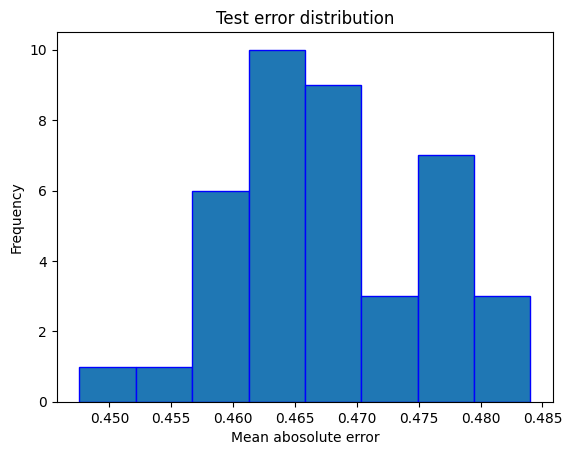

In [24]:
test_error = cv_tree1_result['test_score']
test_error.plot.hist(bins=8, edgecolor="blue")
plt.xlabel('Mean abosolute error')
plt.title('Test error distribution')

In [27]:
print(f'mean cross-validated error = {test_error.mean():.2f}')
print(f'standard deviation cross-validated error = {test_error.std():.2f}')

mean cross-validated error = 0.47
standard deviation cross-validated error = 0.01


Text(0.5, 1.0, 'Target distribution')

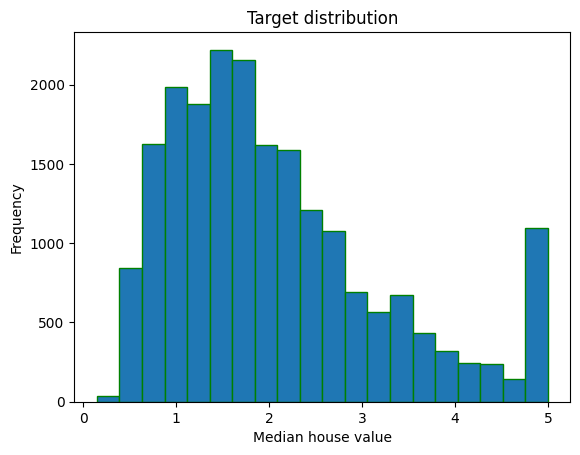

In [30]:
target.plot.hist(bins=20, edgecolor="green")
plt.xlabel("Median house value")
plt.title("Target distribution")

In [31]:
print(f'standard deviation of the target = {target.std():.2f}')

standard deviation of the target = 1.15
